# Tutorial: single-trial E/I population data

The `results/trial_counts_b<N>_<animal>_s<session>.npz` files hold **raw single-trial
spike counts** of the E (wide-spike) and I (narrow-spike) populations — nothing is
averaged, smoothed or normalised. This notebook shows how to

1. choose the trial window (before generating files),
2. load a file and select trials by condition,
3. trim the time axis and rebin,
4. compute trial averages and the paper's baseline-normalised PSTH,
5. pool across mice, and make cross-validation folds.

Full field reference: `DATA.md`. Files are written by `regenerate_population_rates.py`.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

import data_loader

RESULTS = Path("results")
ANIMAL = "M150605_ICTP1"

## 1. Choosing the trial window

Every trial in a file shares one window `[-pre_s, +post_s)` around the first pulse,
set by `PRE_S` / `POST_S` in `regenerate_population_rates.py`. A trial whose window
runs past its experiment's recording is **dropped** (its spikes would come from the
neighbouring experiment). A window can also reach into the *next* trial if the
inter-trial interval is short.

`data_loader.get_trial_margins` reports, for every laser trial, how much recording
there is around its onset. It reads only trial timing (the `.ns5` laser channels),
not spikes, and needs the raw data mounted at `/mnt/scratch`.

pulse experiments (from Protocol xfiles): [2, 3, 4, 5, 6, 7, 13]
  exp 2: 460 trials
  exp 3: 459 trials
  exp 4: 20 trials
  exp 5: 40 trials
  exp 6: 551 trials
  exp 7: 552 trials
  exp 13: 20 trials


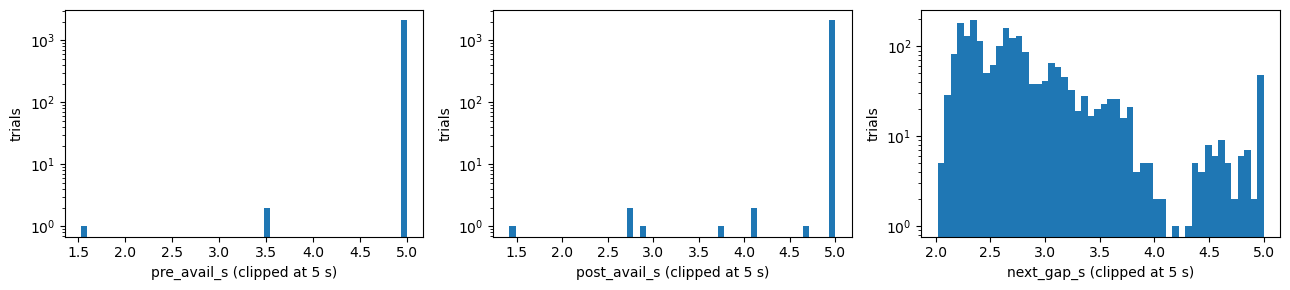

In [2]:
margins = data_loader.get_trial_margins(base_dir=f"/mnt/scratch/{ANIMAL}", animal_id=ANIMAL)

fig, axs = plt.subplots(1, 3, figsize=(13, 3))
for ax, key in zip(axs, ["pre_avail_s", "post_avail_s", "next_gap_s"]):
    v = margins[key][np.isfinite(margins[key])]
    ax.hist(np.minimum(v, 5), bins=50)    # long tail piled into the 5 s bin
    ax.set_yscale("log")                  # the few short margins are what matter
    ax.set_xlabel(f"{key} (clipped at 5 s)"); ax.set_ylabel("trials")
fig.tight_layout()

`window_trial_loss` turns that into a cost for a candidate window:
`n_dropped` trials would be excluded; `n_next_trial_in_window` / `n_prev_trial_in_window`
are kept but overlap a neighbouring trial — your call whether to exclude them downstream.

In [3]:
for pre_s, post_s in [(0.5, 1.5), (0.5, 3.0), (1.0, 1.5), (2.0, 4.0)]:
    print(f"[-{pre_s}, +{post_s}) s:", data_loader.window_trial_loss(margins, pre_s, post_s))

[-0.5, +1.5) s: {'n_trials': 2102, 'n_dropped': 1, 'n_next_trial_in_window': 0, 'n_prev_trial_in_window': 0}
[-0.5, +3.0) s: {'n_trials': 2102, 'n_dropped': 4, 'n_next_trial_in_window': 1550, 'n_prev_trial_in_window': 0}
[-1.0, +1.5) s: {'n_trials': 2102, 'n_dropped': 1, 'n_next_trial_in_window': 0, 'n_prev_trial_in_window': 0}
[-2.0, +4.0) s: {'n_trials': 2102, 'n_dropped': 6, 'n_next_trial_in_window': 1986, 'n_prev_trial_in_window': 0}


## 2. Loading a file and selecting trials

The file is two tables of parallel arrays:

- **trial table** (axis 0 = trial): `counts (n_trials, 2, n_bins)`, `cond_idx`, `exp_num`, `trial_in_exp`, `onset_sample`
- **condition table** (axis 0 = condition): `cond_exp_type`, `cond_ipi_ms`, `cond_dur1_ms`, …

`cond_idx[i]` is the condition row of trial `i`. `counts` axis 1 is `0 = E`, `1 = I`.

In [4]:
d = dict(np.load(RESULTS / f"trial_counts_b300_{ANIMAL}_s1.npz"))
t = d["time_axis"]
bin_s = float(d["bin_samples"] / d["sampling_freq_hz"])

print("counts", d["counts"].shape, d["counts"].dtype, "| bin", bin_s * 1e3, "ms",
      "| window", float(d["pre_s"]), float(d["post_s"]), "| dropped", int(d["n_trials_dropped"]))

counts (2101, 2, 200) uint16 | bin 10.0 ms | window 0.5 1.5 | dropped 1


A quick look at the condition table, with each condition's trial count:

In [5]:
n_per_cond = np.bincount(d["cond_idx"], minlength=d["cond_exp_type"].size)
for k in range(d["cond_exp_type"].size):
    print(f"{k:3d}  {d['cond_exp_type'][k]:10s} ipi={d['cond_ipi_ms'][k]:5d} ms  "
          f"dur={d['cond_dur1_ms'][k]:g}/{d['cond_dur2_ms'][k]:g} ms  n={n_per_cond[k]}")

  0  single_E   ipi=    0 ms  dur=1/nan ms  n=182
  1  single_E   ipi=    0 ms  dur=2/nan ms  n=42
  2  single_I   ipi=    0 ms  dur=1/nan ms  n=202
  3  single_I   ipi=    0 ms  dur=2/nan ms  n=40
  4  paired_EE  ipi=    5 ms  dur=1/1 ms  n=43
  5  paired_EE  ipi=    8 ms  dur=1/1 ms  n=22
  6  paired_EE  ipi=   15 ms  dur=1/1 ms  n=43
  7  paired_EE  ipi=   25 ms  dur=1/1 ms  n=22
  8  paired_EE  ipi=   40 ms  dur=1/1 ms  n=41
  9  paired_EE  ipi=   70 ms  dur=1/1 ms  n=21
 10  paired_EE  ipi=  120 ms  dur=1/1 ms  n=44
 11  paired_EE  ipi=  205 ms  dur=1/1 ms  n=20
 12  paired_EE  ipi=  350 ms  dur=1/1 ms  n=43
 13  paired_EE  ipi=  590 ms  dur=1/1 ms  n=41
 14  paired_EE  ipi=  800 ms  dur=1/1 ms  n=44
 15  paired_EE  ipi= 1000 ms  dur=1/1 ms  n=22
 16  paired_II  ipi=    5 ms  dur=1/1 ms  n=42
 17  paired_II  ipi=    8 ms  dur=1/1 ms  n=22
 18  paired_II  ipi=   15 ms  dur=1/1 ms  n=42
 19  paired_II  ipi=   25 ms  dur=1/1 ms  n=21
 20  paired_II  ipi=   40 ms  dur=1/1 ms  n=43
 21

Selecting trials is a boolean mask on the condition table, mapped to trials through
`cond_idx`. This small helper does that for any combination of condition columns:

In [6]:
def select(d, **criteria):
    """Trial mask for conditions matching all criteria, e.g. exp_type='paired_EE', ipi_ms=50."""
    rows = np.ones(d["cond_exp_type"].size, bool)
    for col, val in criteria.items():
        rows &= d[f"cond_{col}"] == val
    return np.isin(d["cond_idx"], np.flatnonzero(rows))

m = select(d, exp_type="single_E")
print("single_E trials:", m.sum(), "in conditions", np.unique(d["cond_idx"][m]))

single_E trials: 224 in conditions [0 1]


## 3. Trimming and rebinning

Trimming is slicing the last axis. Rebinning sums adjacent bins — exact, since these
are counts (pick a factor that divides `n_bins`).

In [7]:
keep = (t >= -0.2) & (t < 0.5)
x_trim = d["counts"][..., keep]
t_trim = t[keep]

factor = 2                                    # 10 ms -> 20 ms
n = d["counts"].shape[-1] // factor * factor
x_20ms = d["counts"][..., :n].reshape(*d["counts"].shape[:-1], -1, factor).sum(-1)
t_20ms = t[:n].reshape(-1, factor).mean(-1)
print(x_trim.shape, x_20ms.shape)

(2101, 2, 70) (2101, 2, 100)


## 4. Averages and the paper's PSTH

The paper's population activity is the **trial-averaged** rate, divided by its own mean
over the baseline window −0.5 to −0.1 s (and smoothed with a 40 ms Hamming window).
Average first, then normalise: dividing single trials by their own baseline is unstable
(few baseline spikes) and gives a different answer.

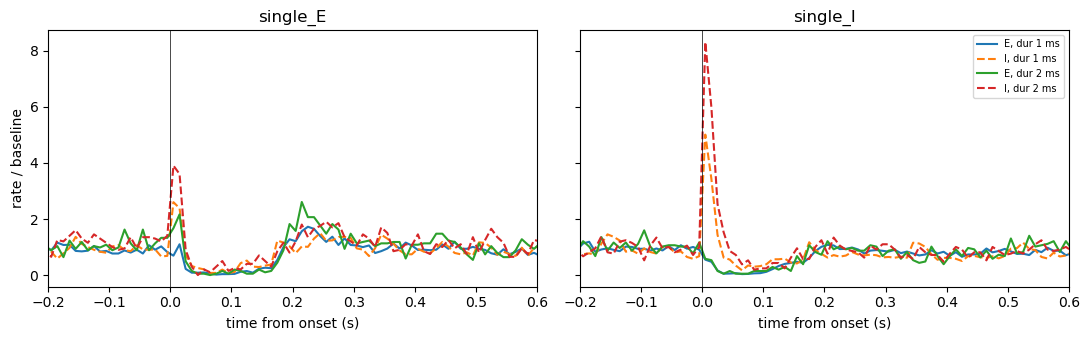

In [8]:
BASELINE = (-0.5, -0.1)

def psth(counts, t, bin_s, baseline=BASELINE, hamming_ms=0.0):
    """Trial-averaged, (optionally Hamming-smoothed), baseline-normalised (2, n_bins)."""
    rate = counts.mean(axis=0) / bin_s                       # Hz
    if hamming_ms > 0:
        w = max(1, round(hamming_ms / 1e3 / bin_s)) | 1      # odd width
        k = np.hamming(w); k /= k.sum()
        rate = np.stack([np.convolve(r, k, mode="same") for r in rate])
    bl = (t >= baseline[0]) & (t < baseline[1])
    return rate / rate[:, bl].mean(axis=1, keepdims=True)

fig, axs = plt.subplots(1, 2, figsize=(11, 3.5), sharey=True)
for ax, exp_type in zip(axs, ["single_E", "single_I"]):
    for k in np.flatnonzero(d["cond_exp_type"] == exp_type):
        p = psth(d["counts"][d["cond_idx"] == k], t, bin_s)
        ax.plot(t, p[0], label=f"E, dur {d['cond_dur1_ms'][k]:g} ms")
        ax.plot(t, p[1], "--", label=f"I, dur {d['cond_dur1_ms'][k]:g} ms")
    ax.axvline(0, color="k", lw=0.5); ax.set_xlim(-0.2, 0.6)
    ax.set_title(exp_type); ax.set_xlabel("time from onset (s)")
axs[0].set_ylabel("rate / baseline"); axs[1].legend(fontsize=7)
fig.tight_layout()

Raw (un-normalised) mean rates in Hz, with trial-to-trial spread, need no extra machinery:

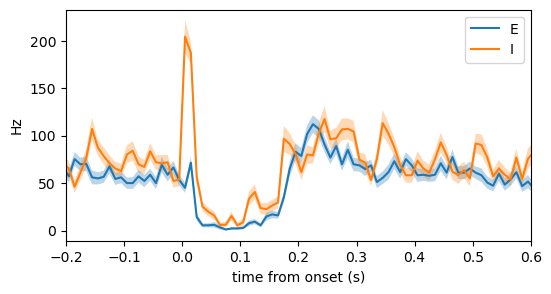

In [9]:
k = np.flatnonzero(d["cond_exp_type"] == "single_E")[0]
rate = d["counts"][d["cond_idx"] == k] / bin_s              # (n, 2, n_bins) Hz
mean, sem = rate.mean(0), rate.std(0, ddof=1) / np.sqrt(len(rate))
plt.figure(figsize=(6, 3))
for pop, name in enumerate("EI"):
    plt.plot(t, mean[pop], label=name)
    plt.fill_between(t, mean[pop] - sem[pop], mean[pop] + sem[pop], alpha=0.3)
plt.xlim(-0.2, 0.6); plt.xlabel("time from onset (s)"); plt.ylabel("Hz"); plt.legend();

## 5. Several mice, and cross-validation folds

Every file has the same keys, so pooling is a loop. Condition sets differ per mouse
(e.g. M151020 sweeps more durations), so match conditions by their columns, not by row
index.

In [10]:
files = sorted(RESULTS.glob("trial_counts_b300_*_s1.npz"))
for f in files:
    di = dict(np.load(f))
    m = select(di, exp_type="paired_EE")
    print(f"{str(di['animal_id']):15s} trials={len(di['counts']):5d}  paired_EE={m.sum():4d}  "
          f"ipis={np.unique(di['cond_ipi_ms'][di['cond_exp_type'] == 'paired_EE']).tolist()}")

M150605_ICTP1   trials= 2101  paired_EE= 406  ipis=[5, 8, 15, 25, 40, 70, 120, 205, 350, 590, 800, 1000]
M150609_ICTP1   trials= 2825  paired_EE= 555  ipis=[5, 8, 15, 25, 40, 70, 120, 205, 350, 590, 800, 1000]
M150609_ICTP2   trials= 2652  paired_EE= 513  ipis=[5, 8, 15, 25, 40, 70, 120, 205, 350, 590, 800, 1000]
M150823_ICTP2   trials= 3241  paired_EE= 749  ipis=[12, 25, 35, 50, 70, 90, 120, 200]
M151020_ICTP1   trials= 2509  paired_EE= 546  ipis=[25, 35, 50, 70, 90, 120, 200]


Folds are now a downstream choice. E.g. a seeded k-fold split within each condition
(what the old `population_rates` files baked in with k = 3, seed 0):

In [11]:
def fold_labels(cond_idx, n_folds=3, seed=0):
    """Fold id per trial; each condition's trials are split as evenly as possible."""
    rng = np.random.default_rng(seed)
    fold = np.empty(cond_idx.size, int)
    for k in np.unique(cond_idx):
        idx = np.flatnonzero(cond_idx == k)
        for f, part in enumerate(np.array_split(rng.permutation(idx), n_folds)):
            fold[part] = f
    return fold

fold = fold_labels(d["cond_idx"])
k = np.flatnonzero(d["cond_exp_type"] == "single_E")[0]
train = psth(d["counts"][(d["cond_idx"] == k) & (fold != 0)], t, bin_s)
test  = psth(d["counts"][(d["cond_idx"] == k) & (fold == 0)], t, bin_s)
print("train/test E PSTH correlation:", np.corrcoef(train[0], test[0])[0, 1].round(3))

train/test E PSTH correlation: 0.806
